# **Universidad de Buenos Aires**
# CEIA - Aprendizaje por Refuerzo I
# Tema: DQN y Dueling DQN en Enduro (Atari)
---
# Trabajo Práctico 3

De acuerdo a la siguiente celda resolver y responder las preguntas modificando el código original y reescribiéndolo luego de cada pregunta.



Esta celda implementa **DQN clásica** y **Dueling DQN** (con replay buffer y red objetivo), ambas entrenadas con exactamente el mismo procedimiento sobre el juego **Enduro** del Atari Learning Environment (ALE).

**Requisitos:** usar un entorno con GPU (*Entorno de ejecución → Cambiar tipo de entorno de ejecución → GPU*).

Dispositivo: cuda
Cantidad de acciones: 9
Entrenando DQN clásica...
  Paso     3323 | ε=0.342 | Episodio   1 | Retorno:    0.0 | Media (últ. 5):    0.0
  Paso     6651 | ε=0.010 | Episodio   2 | Retorno:    0.0 | Media (últ. 5):    0.0
  Paso     9979 | ε=0.010 | Episodio   3 | Retorno:    0.0 | Media (últ. 5):    0.0
  Paso    13300 | ε=0.010 | Episodio   4 | Retorno:    4.0 | Media (últ. 5):    1.0
  Paso    16625 | ε=0.010 | Episodio   5 | Retorno:    0.0 | Media (últ. 5):    0.8
  Paso    19947 | ε=0.010 | Episodio   6 | Retorno:    0.0 | Media (últ. 5):    0.8
  Paso    23275 | ε=0.010 | Episodio   7 | Retorno:    0.0 | Media (últ. 5):    0.8
  Paso    26603 | ε=0.010 | Episodio   8 | Retorno:    0.0 | Media (últ. 5):    0.8
  Paso    29926 | ε=0.010 | Episodio   9 | Retorno:    0.0 | Media (últ. 5):    0.0
  Paso    33252 | ε=0.010 | Episodio  10 | Retorno:    0.0 | Media (últ. 5):    0.0
  Paso    36573 | ε=0.010 | Episodio  11 | Retorno:    0.0 | Media (últ. 5):    0.0
  Paso  

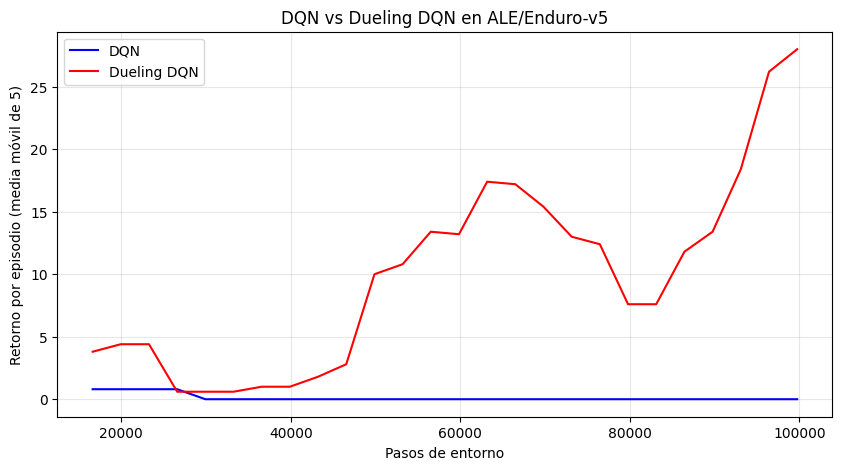


✅ DQN         → retorno medio:     0.0 ± 0.0
✅ Dueling DQN → retorno medio:    20.3 ± 18.7



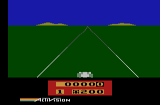
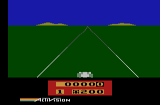

In [ ]:
# ============================================================
# Celda 1: Instalación e imports
# ============================================================
!pip install "gymnasium[atari]" ale-py matplotlib numpy torch pillow -q

import base64
import random
import time
import gc

import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
import ale_py
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from IPython.display import HTML, display

try:
    from gymnasium.wrappers import AtariPreprocessing, FrameStackObservation as FrameStack
except ImportError:  # versiones anteriores de gymnasium
    from gymnasium.wrappers import AtariPreprocessing, FrameStack

if hasattr(gym, "register_envs"):
    gym.register_envs(ale_py)

SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True
print("Dispositivo:", device)

# ============================================================
# Celda 2: Entorno (Enduro) y parámetros
# ============================================================
ENV_ID = "ALE/Enduro-v5"

def make_env(render=False):
    """Enduro con el preprocesamiento clásico de DQN: frame skip 4, 84x84 en grises, 4 cuadros apilados."""
    env = gym.make(
        ENV_ID,
        frameskip=1,                    # el salto de cuadros lo hace AtariPreprocessing
        repeat_action_probability=0.0,  # sin 'sticky actions', como en el paper original
        full_action_space=False,
        render_mode="rgb_array" if render else None,
    )
    env = AtariPreprocessing(env, noop_max=30, frame_skip=4, screen_size=84,
                             terminal_on_life_loss=False, grayscale_obs=True, scale_obs=False)
    env = FrameStack(env, 4)
    return env

_tmp_env = make_env()
N_ACTIONS = _tmp_env.action_space.n          # 9 acciones en Enduro
print("Cantidad de acciones:", N_ACTIONS)
_tmp_env.close()

# --- Hiperparámetros (configuración inicial, deliberadamente deficiente) ---
NUM_STEPS = 100_000          # pasos de entorno por agente (cada paso = 4 cuadros del juego)
GAMMA = 0.99
LR = 1e-3
BATCH_SIZE = 32
BUFFER_SIZE = 1_000          # capacidad del replay buffer
LEARN_START = 1_000          # pasos de experiencia antes de empezar a aprender
TRAIN_EVERY = 4              # una actualización de la red cada 4 pasos de entorno
TARGET_UPDATE_EVERY = 1      # pasos entre cada copia de la red principal a la red objetivo
EPSILON_START = 1.0
EPSILON_END = 0.01
EPSILON_DECAY_STEPS = 5_000  # pasos durante los cuales epsilon decae linealmente

# ============================================================
# Celda 3: Replay buffer (almacena los estados como uint8)
# ============================================================
class ReplayBuffer:
    def __init__(self, capacity):
        self.capacity = capacity
        self.pos = 0
        self.size = 0
        self.s = np.zeros((capacity, 4, 84, 84), dtype=np.uint8)
        self.s2 = np.zeros((capacity, 4, 84, 84), dtype=np.uint8)
        self.a = np.zeros(capacity, dtype=np.int64)
        self.r = np.zeros(capacity, dtype=np.float32)
        self.d = np.zeros(capacity, dtype=np.float32)

    def push(self, s, a, r, s2, done):
        self.s[self.pos] = s
        self.s2[self.pos] = s2
        self.a[self.pos] = a
        self.r[self.pos] = r
        self.d[self.pos] = done
        self.pos = (self.pos + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)

    def sample(self, batch_size):
        idx = np.random.randint(0, self.size, size=batch_size)
        return (
            torch.as_tensor(self.s[idx], device=device),
            torch.as_tensor(self.a[idx], device=device).unsqueeze(1),
            torch.as_tensor(self.r[idx], device=device).unsqueeze(1),
            torch.as_tensor(self.s2[idx], device=device),
            torch.as_tensor(self.d[idx], device=device).unsqueeze(1),
        )

    def __len__(self):
        return self.size

# ============================================================
# Celda 4: Redes neuronales (DQN clásica y Dueling DQN)
# ============================================================
class ConvTrunk(nn.Module):
    """Tronco convolucional común (arquitectura del paper de DQN en Nature)."""
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(4, 32, kernel_size=8, stride=4), nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2), nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1), nn.ReLU(),
            nn.Flatten(),
        )
        self.out_dim = 64 * 7 * 7   # 3136

    def forward(self, x):
        return self.conv(x.float() / 255.0)


class DQN(nn.Module):
    """Red clásica: una sola cabeza que devuelve Q(s, a) para cada acción."""
    def __init__(self, n_actions):
        super().__init__()
        self.trunk = ConvTrunk()
        self.fc = nn.Sequential(nn.Linear(self.trunk.out_dim, 512), nn.ReLU(),
                                nn.Linear(512, n_actions))

    def forward(self, x):
        return self.fc(self.trunk(x))


class DuelingDQN(nn.Module):
    """Red Dueling: mismo tronco, pero dos ramas (V(s) y A(s,a)) que se recombinan."""
    def __init__(self, n_actions):
        super().__init__()
        self.trunk = ConvTrunk()
        self.value = nn.Sequential(nn.Linear(self.trunk.out_dim, 512), nn.ReLU(),
                                   nn.Linear(512, 1))
        self.advantage = nn.Sequential(nn.Linear(self.trunk.out_dim, 512), nn.ReLU(),
                                       nn.Linear(512, n_actions))

    def forward(self, x):
        h = self.trunk(x)
        v = self.value(h)
        a = self.advantage(h)
        # Q(s,a) = V(s) + ( A(s,a) - media_a' A(s,a') )
        return v + a - a.mean(dim=1, keepdim=True)

# ============================================================
# Celda 5: Agente y entrenamiento (idéntico para ambas redes)
# ============================================================
def train_agent(network_class, seed=SEED, num_steps=None, verbose=True):
    num_steps = num_steps or NUM_STEPS
    env = make_env()
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)

    policy_net = network_class(N_ACTIONS).to(device)
    target_net = network_class(N_ACTIONS).to(device)
    target_net.load_state_dict(policy_net.state_dict())
    optimizer = torch.optim.Adam(policy_net.parameters(), lr=LR)
    buffer = ReplayBuffer(BUFFER_SIZE)

    state, _ = env.reset(seed=seed)
    state = np.array(state, dtype=np.uint8)
    ep_return = 0.0
    log_steps, log_returns = [], []
    t0 = time.time()

    for step in range(1, num_steps + 1):
        # Política de comportamiento epsilon-greedy con decaimiento lineal
        epsilon = max(EPSILON_END,
                      EPSILON_START - (EPSILON_START - EPSILON_END) * step / EPSILON_DECAY_STEPS)
        if random.random() < epsilon:
            action = random.randrange(N_ACTIONS)
        else:
            with torch.no_grad():
                s_t = torch.as_tensor(state, device=device).unsqueeze(0)
                action = int(policy_net(s_t).argmax(dim=1).item())

        next_state, reward, terminated, truncated, _ = env.step(action)
        next_state = np.array(next_state, dtype=np.uint8)
        done = terminated or truncated
        # Solo 'terminated' corta el bootstrap (truncated no es un estado terminal real)
        buffer.push(state, action, reward, next_state, float(terminated))
        state = next_state
        ep_return += reward

        if len(buffer) >= max(BATCH_SIZE, LEARN_START) and step % TRAIN_EVERY == 0:
            s, a, r, s2, d = buffer.sample(BATCH_SIZE)
            q_sa = policy_net(s).gather(1, a)
            with torch.no_grad():
                q_next = target_net(s2).max(dim=1, keepdim=True)[0]
                target = r + GAMMA * q_next * (1.0 - d)
            loss = F.mse_loss(q_sa, target)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        if step % TARGET_UPDATE_EVERY == 0:
            target_net.load_state_dict(policy_net.state_dict())

        if done:
            log_steps.append(step)
            log_returns.append(ep_return)
            if verbose:
                print(f"  Paso {step:8d} | ε={epsilon:.3f} | Episodio {len(log_returns):3d} | "
                      f"Retorno: {ep_return:6.1f} | Media (últ. 5): {np.mean(log_returns[-5:]):6.1f}")
            ep_return = 0.0
            state, _ = env.reset()
            state = np.array(state, dtype=np.uint8)

    if verbose:
        print(f"  Tiempo de entrenamiento: {(time.time() - t0) / 60:.1f} min")
    env.close()
    del buffer
    gc.collect()
    if device.type == "cuda":
        torch.cuda.empty_cache()
    return policy_net, np.array(log_steps), np.array(log_returns)

# ============================================================
# Celda 6: Entrenamiento de ambos agentes
# ============================================================
print("Entrenando DQN clásica...")
dqn_net, steps_dqn, returns_dqn = train_agent(DQN)

print("\nEntrenando Dueling DQN...")
dueling_net, steps_dueling, returns_dueling = train_agent(DuelingDQN)

# ============================================================
# Celda 7: Visualización comparativa
# ============================================================
def moving_average(x, w=5):
    w = min(w, len(x))
    return np.convolve(x, np.ones(w) / w, mode='valid')

plt.figure(figsize=(10, 5))
for steps, rets, color, label in [(steps_dqn, returns_dqn, 'blue', 'DQN'),
                                  (steps_dueling, returns_dueling, 'red', 'Dueling DQN')]:
    ma = moving_average(rets)
    plt.plot(steps[len(steps) - len(ma):], ma, color=color, label=label)
plt.xlabel('Pasos de entorno')
plt.ylabel('Retorno por episodio (media móvil de 5)')
plt.title(f'DQN vs Dueling DQN en {ENV_ID}')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ============================================================
# Celda 8: Evaluación de las políticas finales
# ============================================================
EVAL_EPSILON = 0.01   # pequeña exploración para evitar que el agente quede atascado

def evaluate(net, n_eval=3, max_steps=10_000):
    eval_env = make_env()
    scores = []
    for i in range(n_eval):
        state, _ = eval_env.reset(seed=10_000 + i)
        done, total, steps = False, 0.0, 0
        while not done and steps < max_steps:
            if random.random() < EVAL_EPSILON:
                action = random.randrange(N_ACTIONS)
            else:
                with torch.no_grad():
                    s_t = torch.as_tensor(np.array(state, dtype=np.uint8), device=device).unsqueeze(0)
                    action = int(net(s_t).argmax(dim=1).item())
            state, reward, terminated, truncated, _ = eval_env.step(action)
            done = terminated or truncated
            total += reward
            steps += 1
        scores.append(total)
    eval_env.close()
    return np.mean(scores), np.std(scores)

m_dqn, s_dqn = evaluate(dqn_net)
m_duel, s_duel = evaluate(dueling_net)
print(f"\n✅ DQN         → retorno medio: {m_dqn:7.1f} ± {s_dqn:.1f}")
print(f"✅ Dueling DQN → retorno medio: {m_duel:7.1f} ± {s_duel:.1f}")

# ============================================================
# Celda 9: Renderizado en GIF de cada agente
# ============================================================
def record_gif(net, filename, seed=123, max_steps=1500, frame_skip=3):
    """Ejecuta un episodio con la política del agente y guarda el video como GIF."""
    render_env = make_env(render=True)
    state, _ = render_env.reset(seed=seed)
    frames, total, steps = [], 0.0, 0
    done = False
    while not done and steps < max_steps:
        if steps % frame_skip == 0:
            frame = Image.fromarray(render_env.render()).resize((160, 105))
            frames.append(frame)
        if random.random() < EVAL_EPSILON:
            action = random.randrange(N_ACTIONS)
        else:
            with torch.no_grad():
                s_t = torch.as_tensor(np.array(state, dtype=np.uint8), device=device).unsqueeze(0)
                action = int(net(s_t).argmax(dim=1).item())
        state, reward, terminated, truncated, _ = render_env.step(action)
        done = terminated or truncated
        total += reward
        steps += 1
    render_env.close()
    frames[0].save(filename, save_all=True, append_images=frames[1:], duration=50, loop=0)
    return total, steps

ret_d, steps_d = record_gif(dqn_net, "dqn_enduro.gif")
ret_u, steps_u = record_gif(dueling_net, "dueling_dqn_enduro.gif")

def gif_b64(path):
    return base64.b64encode(open(path, "rb").read()).decode()

display(HTML(f"""
<div style="display:flex; gap:30px; align-items:flex-start;">
  <div style="text-align:center">
    <b>DQN</b><br>
    <img src="data:image/gif;base64,{gif_b64('dqn_enduro.gif')}" width="320"><br>
    Autos sobrepasados: {ret_d:.0f} | Pasos: {steps_d}
  </div>
  <div style="text-align:center">
    <b>Dueling DQN</b><br>
    <img src="data:image/gif;base64,{gif_b64('dueling_dqn_enduro.gif')}" width="320"><br>
    Autos sobrepasados: {ret_u:.0f} | Pasos: {steps_u}
  </div>
</div>
"""))


**1.** Con la configuración inicial la red objetivo se actualiza en **cada** paso (`TARGET_UPDATE_EVERY = 1`), es decir, en la práctica no existe. Cambie ese valor a `2_500` pasos y vuelva a entrenar ambas arquitecturas.

¿Qué cambia en las curvas de aprendizaje? Explique por qué un objetivo `r + γ·max Q` calculado con los mismos parámetros que se están actualizando produce un "blanco móvil" inestable, y qué hace la red objetivo para evitarlo. (VALOR EJERCICIO 0.4)

In [ ]:
# Pregunta 1: cambie TARGET_UPDATE_EVERY a 2_500, vuelva a entrenar ambas arquitecturas y compare las curvas


Respuesta

**2.** Manteniendo el cambio anterior, reemplace la pérdida `F.mse_loss` por la pérdida de Huber (`F.smooth_l1_loss`), agregue recorte de gradiente (`nn.utils.clip_grad_norm_(policy_net.parameters(), 10.0)` antes de `optimizer.step()`) y reduzca la tasa de aprendizaje a `LR = 1e-4`.

¿Qué efecto tiene cada cambio sobre la estabilidad del entrenamiento? ¿Por qué un error de TD muy grande es especialmente dañino con la pérdida cuadrática? (VALOR EJERCICIO 0.4)

In [ ]:
# Pregunta 2: agregue pérdida de Huber, recorte de gradiente y LR = 1e-4 (manteniendo los cambios anteriores) y compare


Respuesta

**3.** Manteniendo los cambios anteriores, aumente el replay buffer a `BUFFER_SIZE = 50_000` y retrase el inicio del aprendizaje con `LEARN_START = 5_000`.

Calcule cuánta memoria ocupa el buffer (cada estado son 4×84×84 bytes y se guardan `s` y `s2`) y explique por qué un buffer demasiado chico es un problema: ¿qué ocurre con la correlación entre las muestras de un lote y con el olvido de experiencias pasadas? (VALOR EJERCICIO 0.4)

In [ ]:
# Pregunta 3: aumente BUFFER_SIZE a 50_000 y LEARN_START a 5_000, calcule la memoria del buffer y compare


Respuesta

**4.** Manteniendo los cambios anteriores, prolongue la fase de exploración aumentando `EPSILON_DECAY_STEPS` a `100_000` (y suba `NUM_STEPS` a `200_000` para que quede tiempo de explotación después del decaimiento).

¿Qué ocurre si epsilon llega a su mínimo demasiado pronto, cuando la red todavía no aprendió casi nada? ¿Qué se observa ahora en la diferencia entre DQN y Dueling DQN? (VALOR EJERCICIO 0.4)

In [ ]:
# Pregunta 4: aumente EPSILON_DECAY_STEPS a 100_000 y NUM_STEPS a 200_000 y compare ambas arquitecturas


Respuesta

**5.** Manteniendo los cambios anteriores, aumente `NUM_STEPS` a `500_000` (con `EPSILON_DECAY_STEPS = 250_000`) y entrene ambas arquitecturas. Calcule, además de la curva, el retorno medio de los últimos 20 episodios de cada una y evalúelas con `evaluate`.

¿Qué arquitectura aprende más rápido y cuál alcanza mejor retorno final? ¿Cuántos pasos necesita cada una para superar un retorno determinado (por ejemplo, el doble del retorno de una política aleatoria)? Si la diferencia entre ambas es pequeña, ¿qué podría hacerla más clara? (VALOR EJERCICIO 0.4)

In [ ]:
# Pregunta 5: use NUM_STEPS = 500_000 y EPSILON_DECAY_STEPS = 250_000; calcule retorno final de los últimos 20 episodios y evalúe


Respuesta

**6.** Con las redes entrenadas en la pregunta anterior, tome un episodio de `dueling_net` y, en cada paso, calcule por separado V(s) y A(s, a) ejecutando a mano `trunk`, `value` y `advantage`. Verifique numéricamente que `Q = V + A − media(A)` coincide con la salida de la red. Grafique en el tiempo la dispersión de las ventajas `max_a A(s,a) − min_a A(s,a)` junto con V(s).

¿En qué momentos del juego las ventajas se parecen entre sí (la acción importa poco) y en cuáles se separan (la acción es crítica)? Relacione lo observado con la ventaja de la arquitectura Dueling en un juego como Enduro. Pista: pruebe también con frames en los que hay un auto justo adelante. (VALOR EJERCICIO 0.4)

In [ ]:
# Pregunta 6: extraiga V(s) y A(s,a) de dueling_net a lo largo de un episodio, verifique Q = V + A - media(A) y grafique la dispersión de las ventajas


Respuesta

**7.** Con la configuración final, entrene ambas arquitecturas con al menos **2 semillas** distintas cada una (argumento `seed` de `train_agent`), grafique la curva promedio con su desvío entre semillas, evalúe las políticas finales y genere los GIF de los mejores agentes de cada arquitectura.

¿Se observa que Dueling DQN supera a DQN? Explique el resultado a partir de lo visto en la pregunta 6 y de lo que reporta el paper original, y mencione al menos dos limitaciones de sacar conclusiones con tan pocas semillas y pasos de entrenamiento. (VALOR EJERCICIO 0.9)

In [ ]:
# Pregunta 7: entrene ambas arquitecturas con al menos 2 semillas, grafique promedio y desvío, evalúe y genere los GIF


Respuesta